# EuroSAT Fine-tune Notebook (Groupmate Pretraining)

This is a **fine-tuning** notebook based on `Colab/eurosat_linearProb_colab.ipynb`, but it swaps the CACo checkpoint download flow with your **groupmates' pretraining checkpoint** flow.

Key change: before training, we normalize your teammate checkpoint into CACo-compatible format using `scripts/normalize_pretrain_checkpoint.py`.


## Step 1: Install Dependencies

In [4]:
%pip install -q torchvision scikit-learn pillow tqdm pandas

Note: you may need to restart the kernel to use updated packages.


## Step 2: Project Setup (replaces CACo clone step)

This notebook expects to run from the project root (the folder that contains `caco/`, `scripts/`, and `data/`).

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "caco" / "src").exists():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / "caco" / "src").exists():
            PROJECT_ROOT = candidate
            break
    else:
        raise FileNotFoundError(
            f"Could not find caco/src starting from {Path.cwd()} and its parents. "
            "Open this notebook from the repo root (or a subdirectory inside it)."
        )

sys.path.insert(0, str(PROJECT_ROOT / "caco" / "src"))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Added to sys.path:", PROJECT_ROOT / "caco" / "src")

PROJECT_ROOT: /Users/jimmylin/Documents/GitHub/School/CSCI1470HW/Final Project
Added to sys.path: /Users/jimmylin/Documents/GitHub/School/CSCI1470HW/Final Project/caco/src


## Step 3: Imports

In [6]:
import shutil
import subprocess
from urllib import request

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms as T
import matplotlib.pyplot as plt

from datasets.eurosat_dataset import EurosatDataset
from utils.downstream_utils import build_feature_extractor, seed_everything

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Step 4: Normalize Groupmate Pretraining Checkpoint

Set `TEAMMATE_CKPT` to your in-house checkpoint (`.ckpt/.pt/.pth`).
The script converts it into a CACo-compatible checkpoint for EuroSAT finetuning.

In [7]:
BASE_ENCODER = "resnet18"
TEAMMATE_CKPT = PROJECT_ROOT / "checkpoints" / "resnet18_caco_geo_100k_1000.pth"  # <-- change to your groupmate checkpoint if different
NORMALIZED_CKPT = PROJECT_ROOT / "results" / "notebooks" / "eurosat_finetune" / "teammate_resnet18_caco_compatible.pt"

if not TEAMMATE_CKPT.exists():
    raise FileNotFoundError(f"Checkpoint not found: {TEAMMATE_CKPT}")

cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "normalize_pretrain_checkpoint.py"),
    "--input_ckpt", str(TEAMMATE_CKPT),
    "--output_ckpt", str(NORMALIZED_CKPT),
    "--base_encoder", BASE_ENCODER,
    "--overwrite",
]
subprocess.run(cmd, check=True)
print("Normalized checkpoint:", NORMALIZED_CKPT)

[ok] wrote normalized checkpoint to /Users/jimmylin/Documents/GitHub/School/CSCI1470HW/Final Project/results/notebooks/eurosat_finetune/teammate_resnet18_caco_compatible.pt (kept=120, skipped=0)
Normalized checkpoint: /Users/jimmylin/Documents/GitHub/School/CSCI1470HW/Final Project/results/notebooks/eurosat_finetune/teammate_resnet18_caco_compatible.pt


## Step 5: Download EuroSAT Dataset (if needed)

In [8]:
DATA_DIR = PROJECT_ROOT / "data"
EUROSAT_DIR = DATA_DIR / "eurosat" / "EuroSAT_RGB"
ZIP_PATH = DATA_DIR / "eurosat" / "EuroSAT_RGB.zip"
DOWNLOAD_URL = "https://research.cs.cornell.edu/caco/data/eurosat/EuroSAT_RGB.zip"
SPLIT_URL = "https://research.cs.cornell.edu/caco/data/eurosat"

(DATA_DIR / "eurosat").mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    print("Downloading EuroSAT dataset...")
    request.urlretrieve(DOWNLOAD_URL, ZIP_PATH)
    print("Download complete.")

if not EUROSAT_DIR.exists():
    print("Extracting EuroSAT...")
    shutil.unpack_archive(str(ZIP_PATH), str(DATA_DIR / "eurosat"))

for split in ["train.txt", "val.txt", "all.txt"]:
    split_path = EUROSAT_DIR / split
    if not split_path.exists():
        request.urlretrieve(f"{SPLIT_URL}/{split}", split_path)

print("EuroSAT ready at:", EUROSAT_DIR)

EuroSAT ready at: /Users/jimmylin/Documents/GitHub/School/CSCI1470HW/Final Project/data/eurosat/EuroSAT_RGB


## Step 6: DataLoaders

In [9]:
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = EurosatDataset(str(EUROSAT_DIR), split="train", transform=transform)
val_dataset = EurosatDataset(str(EUROSAT_DIR), split="val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Classes ({NUM_CLASSES}): {train_dataset.classes}")

Train samples: 16200
Val samples:   5400
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Step 7: Finetune Helpers

In [10]:
class EuroSatClassifier(nn.Module):
    def __init__(self, backbone: nn.Module, in_features: int, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        return self.classifier(features)


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)
        total_loss += float(loss.detach().item()) * batch_size
        total_correct += int((logits.argmax(dim=1) == labels).sum().item())
        total_samples += int(batch_size)

    mean_loss = total_loss / max(total_samples, 1)
    mean_acc = 100.0 * total_correct / max(total_samples, 1)
    return mean_loss, mean_acc


def run_finetune_experiment(name, backbone_type, ckpt_path=None, num_epochs=10, learning_rate=1e-5):
    print(f"\n===== {name} ({backbone_type}, finetune) =====")

    backbone, in_features = build_feature_extractor(
        backbone_type=backbone_type,
        base_encoder=BASE_ENCODER,
        ckpt_path=(str(ckpt_path) if ckpt_path is not None else None),
    )
    model = EuroSatClassifier(backbone=backbone, in_features=in_features, num_classes=NUM_CLASSES).to(device)

    for param in model.backbone.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0)
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[max(1, int(0.6 * num_epochs)), max(1, int(0.8 * num_epochs))],
        gamma=0.1,
    )
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%"
        )

    print(f"Best val acc: {best_val_acc:.2f}%")
    return best_val_acc


print("Finetune helpers ready.")

Finetune helpers ready.


## Step 8: Run EuroSAT Finetune

This runs your **groupmate pretrain** setup. Optionally enable baselines for comparison.

In [11]:
seed_everything(42)

NUM_EPOCHS = 10
RUN_BASELINES = True

results = {}
results["Groupmate Pretrain"] = run_finetune_experiment(
    name="Groupmate Pretrain",
    backbone_type="pretrain",
    ckpt_path=NORMALIZED_CKPT,
    num_epochs=NUM_EPOCHS,
    learning_rate=1e-5,
)

if RUN_BASELINES:
    results["ImageNet"] = run_finetune_experiment(
        name="ImageNet",
        backbone_type="imagenet",
        ckpt_path=None,
        num_epochs=NUM_EPOCHS,
        learning_rate=1e-5,
    )
    results["Random Init"] = run_finetune_experiment(
        name="Random Init",
        backbone_type="random",
        ckpt_path=None,
        num_epochs=NUM_EPOCHS,
        learning_rate=1e-5,
    )

print("\nFinal best-val results:")
for method, score in results.items():
    print(f"{method:20s}: {score:.2f}%")


===== Groupmate Pretrain (pretrain, finetune) =====
Epoch 001/10 | train_loss=1.8676 train_acc=58.49% | val_loss=1.3690 val_acc=82.67%
Epoch 002/10 | train_loss=1.1504 train_acc=86.82% | val_loss=0.8549 val_acc=91.22%
Epoch 003/10 | train_loss=0.7452 train_acc=90.94% | val_loss=0.5263 val_acc=93.09%
Epoch 004/10 | train_loss=0.5055 train_acc=92.77% | val_loss=0.3617 val_acc=94.31%
Epoch 005/10 | train_loss=0.3764 train_acc=93.64% | val_loss=0.2728 val_acc=95.30%
Epoch 006/10 | train_loss=0.2942 train_acc=94.42% | val_loss=0.2179 val_acc=95.69%
Epoch 007/10 | train_loss=0.2665 train_acc=94.91% | val_loss=0.2197 val_acc=95.80%
Epoch 008/10 | train_loss=0.2529 train_acc=95.40% | val_loss=0.2109 val_acc=95.93%
Epoch 009/10 | train_loss=0.2501 train_acc=95.42% | val_loss=0.2120 val_acc=95.93%
Epoch 010/10 | train_loss=0.2571 train_acc=95.23% | val_loss=0.2168 val_acc=95.96%
Best val acc: 95.96%

===== ImageNet (imagenet, finetune) =====
Epoch 001/10 | train_loss=1.1664 train_acc=65.54% | v

## Step 9: Plot Results

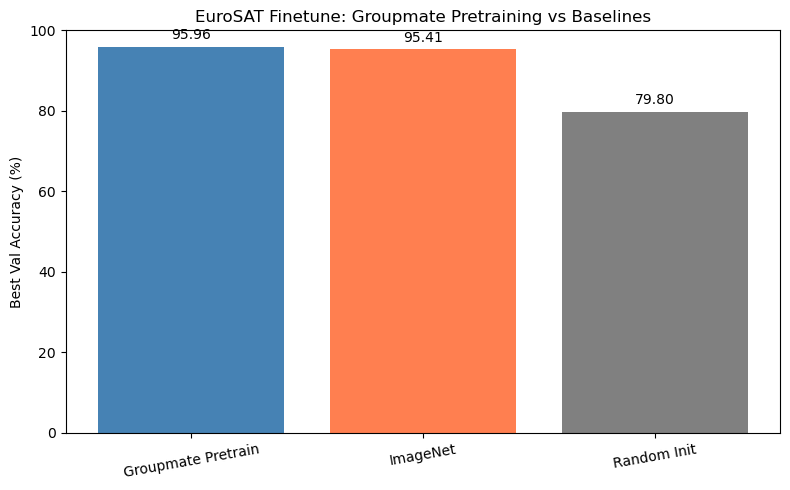

In [12]:
methods = list(results.keys())
scores = [results[m] for m in methods]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, scores, color=["steelblue", "coral", "gray"][: len(methods)])
ax.set_ylabel("Best Val Accuracy (%)")
ax.set_title("EuroSAT Finetune: Groupmate Pretraining vs Baselines")
ax.set_ylim(0, 100)
ax.bar_label(bars, fmt="%.2f", padding=3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()